# MWE 17 - Solver-options benchmark for constant and variable viscosity

This notebook benchmarks the solver configurations currently available in `voids`.

It has three sections:
1. Network constant-viscosity linear solves
2. Network pressure-dependent viscosity solves using both Picard and damped Newton
3. FEM micro-continuum linear backend comparison with PETSc, SciPy, and UMFPACK

Scientific scope:
- the geometry is fixed so the comparison isolates solver behavior
- all runs report the same physical quantity (`Kabs`) and are compared against a reference solve
- the PyAMG path is treated as a linear preconditioner, not as a different physical model
- FEM backend comparisons keep the same DOLFINx/UFL weak form and boundary conditions; only the
  assembled linear algebra backend changes

In [8]:
from __future__ import annotations

import sys
from pathlib import Path
from statistics import median
from time import perf_counter

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - plain Python fallback for minimal environments
    display = print

from voids.examples import make_cartesian_mesh_network
from voids.fem.singlephase import (
    FEMMapProblem,
    FEniCSSolverOptions,
    solve_brinkman_taylor_hood,
    solve_brinkman_usfem,
    solve_darcy_taylor_hood,
)
from voids.fem.singlephase._common import _require_dolfinx_core
from voids.image.porosity import PermeabilityMap, PorosityMap
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.physics.thermo import TabulatedWaterViscosityModel

plt.style.use("seaborn-v0_8-whitegrid")

In [9]:
def find_notebooks_base() -> Path:
    """Return the notebook root used for saved figures and CSV artifacts."""

    from os import environ

    if "VOIDS_NOTEBOOKS_PATH" in environ:
        return Path(environ["VOIDS_NOTEBOOKS_PATH"]).expanduser().resolve()

    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "notebooks").is_dir() and (
            candidate / "jupytext.toml"
        ).exists():
            return candidate / "notebooks"
    return cwd


NET = make_cartesian_mesh_network(
    (35, 35),
    spacing=1.0,
    thickness=1.0,
    pore_radius=0.22,
    throat_radius=0.09,
)
CONDUCTANCE_MODEL = "valvatne_blunt"
LINEAR_BC = PressureBC("inlet_xmin", "outlet_xmax", pin=1.0, pout=0.0)
NONLINEAR_BC = PressureBC("inlet_xmin", "outlet_xmax", pin=8.0e6, pout=5.0e6)
THERMO_MODEL = TabulatedWaterViscosityModel.from_backend(
    "thermo",
    temperature=298.15,
    pressure_points=192,
)
REFERENCE_MU = THERMO_MODEL.reference_viscosity(
    pin=NONLINEAR_BC.pin, pout=NONLINEAR_BC.pout
)
REPEATS = 3
FEM_REPEATS = 3
FEM_SHAPES = [(5, 5), (10, 10), (20, 20)]
NOTEBOOKS_BASE = find_notebooks_base()
OUTPUT_DIR = NOTEBOOKS_BASE / "outputs" / "17_mwe_solver_options_benchmark"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DOCS_ASSET_DIR = NOTEBOOKS_BASE.parent / "docs" / "assets" / "solver_backends"
DOCS_ASSET_DIR.mkdir(parents=True, exist_ok=True)

constant_configs = {
    "direct": SinglePhaseOptions(conductance_model=CONDUCTANCE_MODEL, solver="direct"),
    "direct_umfpack": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="umfpack",
    ),
    "cg": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="cg",
        solver_parameters={"rtol": 1.0e-10, "maxiter": 3_000},
    ),
    "cg_pyamg": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="cg",
        solver_parameters={
            "rtol": 1.0e-10,
            "maxiter": 3_000,
            "preconditioner": "pyamg",
        },
    ),
    "gmres": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="gmres",
        solver_parameters={"rtol": 1.0e-10, "maxiter": 800, "restart": 80},
    ),
    "gmres_pyamg": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="gmres",
        solver_parameters={
            "rtol": 1.0e-10,
            "maxiter": 800,
            "restart": 80,
            "preconditioner": "pyamg",
        },
    ),
}
variable_configs = {
    "picard_direct": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="direct",
        nonlinear_solver="picard",
        nonlinear_pressure_tolerance=1.0e-10,
    ),
    "picard_umfpack": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="umfpack",
        nonlinear_solver="picard",
        nonlinear_pressure_tolerance=1.0e-10,
    ),
    "picard_gmres_pyamg": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="gmres",
        nonlinear_solver="picard",
        nonlinear_pressure_tolerance=1.0e-10,
        solver_parameters={
            "rtol": 1.0e-10,
            "maxiter": 800,
            "restart": 80,
            "preconditioner": "pyamg",
        },
    ),
    "newton_direct": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="direct",
        nonlinear_solver="newton",
        nonlinear_pressure_tolerance=1.0e-10,
    ),
    "newton_umfpack": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="umfpack",
        nonlinear_solver="newton",
        nonlinear_pressure_tolerance=1.0e-10,
    ),
    "newton_gmres": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="gmres",
        nonlinear_solver="newton",
        nonlinear_pressure_tolerance=1.0e-10,
        solver_parameters={"rtol": 1.0e-10, "maxiter": 800, "restart": 80},
    ),
    "newton_gmres_pyamg": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="gmres",
        nonlinear_solver="newton",
        nonlinear_pressure_tolerance=1.0e-10,
        solver_parameters={
            "rtol": 1.0e-10,
            "maxiter": 800,
            "restart": 80,
            "preconditioner": "pyamg",
        },
    ),
}
fem_solver_configs = {
    "petsc_mumps": FEniCSSolverOptions.direct_lu("mumps"),
    "scipy_spsolve": FEniCSSolverOptions.scipy_direct(),
    "umfpack": FEniCSSolverOptions.umfpack_direct(),
}
fem_formulations = {
    "darcy_taylor_hood": solve_darcy_taylor_hood,
    "brinkman_taylor_hood": solve_brinkman_taylor_hood,
    "brinkman_usfem": solve_brinkman_usfem,
}

In [10]:
def benchmark_case(
    *,
    fluid: FluidSinglePhase,
    bc: PressureBC,
    axis: str,
    options: SinglePhaseOptions,
    repeats: int,
) -> tuple[dict[str, float], object]:
    """Run one solver configuration multiple times and summarize timing."""

    times: list[float] = []
    last_result = None
    for _ in range(repeats):
        tic = perf_counter()
        last_result = solve(
            NET,
            fluid=fluid,
            bc=bc,
            axis=axis,
            options=options,
        )
        times.append(perf_counter() - tic)
    assert last_result is not None
    return (
        {
            "time_median_s": median(times),
            "time_min_s": min(times),
            "time_max_s": max(times),
        },
        last_result,
    )


def finalize_figure(fig) -> None:
    """Show figures in notebooks and close them in non-interactive script runs."""

    backend = matplotlib.get_backend().lower()
    if "agg" in backend:
        plt.close(fig)
    else:
        plt.show()


def save_figure(fig, name: str) -> None:
    """Save a figure to notebook outputs and public docs assets."""

    for directory in (OUTPUT_DIR, DOCS_ASSET_DIR):
        fig.savefig(directory / name, dpi=170, bbox_inches="tight")


def save_table(df: pd.DataFrame, name: str) -> None:
    """Save a table to notebook outputs and public docs assets."""

    for directory in (OUTPUT_DIR, DOCS_ASSET_DIR):
        df.to_csv(directory / name, index=False)


def summarize_configs(
    *,
    title: str,
    fluid: FluidSinglePhase,
    bc: PressureBC,
    configs: dict[str, SinglePhaseOptions],
    reference_label: str,
) -> pd.DataFrame:
    """Benchmark a set of solver configurations and compare against one reference run."""

    rows: list[dict[str, float | str]] = []
    reference_kabs = None
    reference_q = None
    for label, options in configs.items():
        timing, result = benchmark_case(
            fluid=fluid,
            bc=bc,
            axis="x",
            options=options,
            repeats=REPEATS,
        )
        if label == reference_label:
            reference_kabs = result.permeability["x"]
            reference_q = result.total_flow_rate
        rows.append(
            {
                "section": title,
                "config": label,
                "solver": options.solver,
                "nonlinear_solver": options.nonlinear_solver,
                "linear_backend": str(
                    result.solver_info.get("backend", options.solver)
                ),
                "kabs": result.permeability["x"],
                "Q": result.total_flow_rate,
                "residual_norm": result.residual_norm,
                "mass_balance_error": result.mass_balance_error,
                "linear_info": float(result.solver_info.get("info", 0)),
                "nonlinear_iterations": float(
                    result.solver_info.get("nonlinear_iterations", 0)
                ),
                **timing,
            }
        )
    assert reference_kabs is not None and reference_q is not None
    df = pd.DataFrame(rows)
    df["kabs_rel_diff_to_reference"] = (df["kabs"] - reference_kabs) / reference_kabs
    df["Q_rel_diff_to_reference"] = (df["Q"] - reference_q) / reference_q
    return df


def fem_stack_status() -> tuple[bool, str]:
    """Return whether the DOLFINx core stack needed by FEM notebooks is available."""

    try:
        _require_dolfinx_core()
    except ImportError as exc:
        return False, str(exc)
    return True, "DOLFINx core imports are available."


def constant_fem_problem(
    shape: tuple[int, int], permeability: float = 2.0
) -> FEMMapProblem:
    """Build a homogeneous 2-D FEM map problem with matching porosity and permeability grids."""

    return FEMMapProblem(
        permeability_map=PermeabilityMap(np.full(shape, permeability), cell_size=1.0),
        porosity_map=PorosityMap(np.ones(shape), cell_size=1.0),
        viscosity=1.0,
    )


def relative_l2(candidate: np.ndarray, reference: np.ndarray) -> float:
    """Return the relative L2 norm of two arrays using an absolute norm for zero references."""

    reference_norm = float(np.linalg.norm(reference))
    difference_norm = float(np.linalg.norm(candidate - reference))
    if reference_norm == 0.0:
        return difference_norm
    return difference_norm / reference_norm


def benchmark_fem_case(
    *,
    problem: FEMMapProblem,
    solver,
    options: FEniCSSolverOptions,
    repeats: int,
) -> tuple[dict[str, float], object]:
    """Run one FEM formulation/backend pair multiple times and summarize timing."""

    times: list[float] = []
    last_result = None
    for _ in range(repeats):
        tic = perf_counter()
        last_result = solver(problem, flow_axis="x", options=options)
        times.append(perf_counter() - tic)
    assert last_result is not None
    return (
        {
            "time_median_s": median(times),
            "time_min_s": min(times),
            "time_max_s": max(times),
            "reported_solve_seconds": float(last_result.solve_seconds),
        },
        last_result,
    )


def summarize_fem_backends() -> tuple[pd.DataFrame, pd.DataFrame, str]:
    """Benchmark FEM linear backends and compare solution arrays within each formulation/mesh."""

    available, message = fem_stack_status()
    if not available:
        return pd.DataFrame(), pd.DataFrame(), message

    rows: list[dict[str, float | int | str]] = []
    failure_rows: list[dict[str, int | str]] = []
    successful_results: dict[tuple[str, str, int], object] = {}
    for shape in FEM_SHAPES:
        problem = constant_fem_problem(shape)
        cells = int(np.prod(shape))
        for formulation, solver in fem_formulations.items():
            for backend_label, options in fem_solver_configs.items():
                try:
                    timing, result = benchmark_fem_case(
                        problem=problem,
                        solver=solver,
                        options=options,
                        repeats=FEM_REPEATS,
                    )
                except (ImportError, NotImplementedError, RuntimeError) as exc:
                    failure_rows.append(
                        {
                            "formulation": formulation,
                            "backend": backend_label,
                            "cells": cells,
                            "status": type(exc).__name__,
                            "message": str(exc),
                        }
                    )
                    continue

                successful_results[(formulation, backend_label, cells)] = result
                rows.append(
                    {
                        "formulation": formulation,
                        "backend": backend_label,
                        "resolved_backend": str(result.metadata["linear_backend"]),
                        "cells": cells,
                        "permeability": float(result.permeability),
                        "flow_rate": float(result.flow_rate),
                        "velocity_dofs": int(result.velocity.x.array.size),
                        "pressure_dofs": int(result.pressure.x.array.size),
                        **timing,
                    }
                )

    df = pd.DataFrame(rows)
    if df.empty:
        return df, pd.DataFrame(failure_rows), message

    for (formulation, cells), group in df.groupby(["formulation", "cells"]):
        available_backends = group["backend"].tolist()
        if "petsc_mumps" in available_backends:
            reference_backend = "petsc_mumps"
        elif "scipy_spsolve" in available_backends:
            reference_backend = "scipy_spsolve"
        else:
            reference_backend = str(available_backends[0])

        reference = successful_results[
            (str(formulation), reference_backend, int(cells))
        ]
        reference_velocity = np.asarray(reference.velocity.x.array, dtype=float)
        reference_pressure = np.asarray(reference.pressure.x.array, dtype=float)
        reference_permeability = float(reference.permeability)
        reference_flow_rate = float(reference.flow_rate)

        mask = (df["formulation"] == formulation) & (df["cells"] == cells)
        df.loc[mask, "reference_backend"] = reference_backend
        df.loc[mask, "permeability_rel_diff_to_reference"] = (
            df.loc[mask, "permeability"] - reference_permeability
        ) / reference_permeability
        df.loc[mask, "flow_rate_rel_diff_to_reference"] = (
            df.loc[mask, "flow_rate"] - reference_flow_rate
        ) / reference_flow_rate

        for index, row in df.loc[mask].iterrows():
            result = successful_results[
                (str(formulation), str(row["backend"]), int(cells))
            ]
            df.loc[index, "velocity_rel_l2_to_reference"] = relative_l2(
                np.asarray(result.velocity.x.array, dtype=float),
                reference_velocity,
            )
            df.loc[index, "pressure_rel_l2_to_reference"] = relative_l2(
                np.asarray(result.pressure.x.array, dtype=float),
                reference_pressure,
            )

    return df, pd.DataFrame(failure_rows), message

## Benchmark design

This notebook is intended to answer two separate numerical questions:
- which linear solver/preconditioner pair is most efficient for the constant-viscosity pressure solve
- whether Picard or Newton is the better outer strategy once viscosity depends on pressure

The same mesh network is used throughout, and each configuration is benchmarked multiple times so the
tables report representative rather than single-shot timings.

In [11]:
design_df = pd.DataFrame(
    {
        "quantity": [
            "mesh_shape",
            "pore_radius",
            "throat_radius",
            "conductance_model",
            "constant_reference_viscosity [Pa s]",
            "nonlinear_pin [MPa]",
            "nonlinear_pout [MPa]",
            "repeats_per_configuration",
            "fem_map_shapes",
            "fem_repeats_per_configuration",
        ],
        "value": [
            str((35, 35)),
            0.22,
            0.09,
            CONDUCTANCE_MODEL,
            REFERENCE_MU,
            NONLINEAR_BC.pin / 1.0e6,
            NONLINEAR_BC.pout / 1.0e6,
            REPEATS,
            str(FEM_SHAPES),
            FEM_REPEATS,
        ],
    }
)
design_df

,quantity,value
0,mesh_shape,"(35, 35)"
1,pore_radius,0.22
2,throat_radius,0.09
3,conductance_model,valvatne_blunt
4,constant_reference_viscosity [Pa s],0.000889
5,nonlinear_pin [MPa],8.0
6,nonlinear_pout [MPa],5.0
7,repeats_per_configuration,3


## Constant-viscosity benchmark

This is the easiest case for AMG because the pressure matrix is the standard linear elliptic operator.

In [12]:
constant_df = summarize_configs(
    title="constant_viscosity",
    fluid=FluidSinglePhase(viscosity=REFERENCE_MU),
    bc=LINEAR_BC,
    configs=constant_configs,
    reference_label="direct",
)
constant_df
save_table(constant_df, "constant_solver_benchmark.csv")

In [13]:
constant_ranked = constant_df.sort_values("time_median_s")[
    [
        "config",
        "solver",
        "linear_backend",
        "time_median_s",
        "kabs_rel_diff_to_reference",
        "Q_rel_diff_to_reference",
    ]
]
constant_ranked

,config,time_median_s,kabs_rel_diff_to_reference,Q_rel_diff_to_reference,solver
1,cg,0.008954,-3.860261e-14,-3.847776e-14,cg
0,direct,0.010435,0.000000e+00,0.000000e+00,direct
2,cg_pyamg,0.013541,1.311848e-09,1.311848e-09,cg
4,gmres_pyamg,0.013940,4.458657e-10,4.458657e-10,gmres
3,gmres,0.020286,-2.588130e-14,-2.582936e-14,gmres


## Variable-viscosity benchmark

The nonlinear runs use absolute pressures and the same thermodynamic viscosity model as the previous
notebook. Here the question is not only linear-solver speed but also whether Picard or Newton is the
better outer strategy.

In [14]:
variable_df = summarize_configs(
    title="variable_viscosity",
    fluid=FluidSinglePhase(viscosity_model=THERMO_MODEL),
    bc=NONLINEAR_BC,
    configs=variable_configs,
    reference_label="newton_direct",
)
variable_df
save_table(variable_df, "variable_solver_benchmark.csv")

In [15]:
variable_ranked = variable_df.sort_values("time_median_s")[
    [
        "config",
        "solver",
        "linear_backend",
        "time_median_s",
        "nonlinear_iterations",
        "kabs_rel_diff_to_reference",
        "Q_rel_diff_to_reference",
    ]
]
variable_ranked

,config,time_median_s,nonlinear_iterations,kabs_rel_diff_to_reference,Q_rel_diff_to_reference
2,newton_direct,0.018524,2.0,0.000000e+00,0.000000e+00
4,newton_gmres_pyamg,0.026856,2.0,0.000000e+00,0.000000e+00
3,newton_gmres,0.029893,2.0,0.000000e+00,0.000000e+00
0,picard_direct,0.051843,3.0,2.522333e-13,2.522264e-13
1,picard_gmres_pyamg,0.068730,3.0,2.836144e-09,2.836144e-09


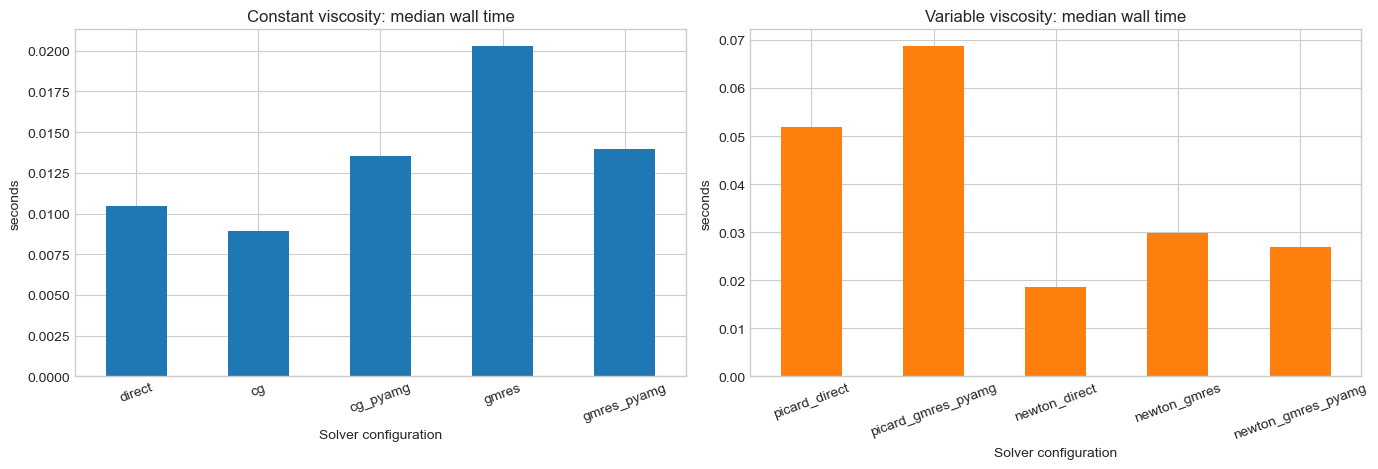

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

constant_df.plot(
    x="config",
    y="time_median_s",
    kind="bar",
    ax=axes[0],
    legend=False,
    color="tab:blue",
    rot=20,
)
axes[0].set_title("Constant viscosity: median wall time")
axes[0].set_xlabel("Solver configuration")
axes[0].set_ylabel("seconds")

variable_df.plot(
    x="config",
    y="time_median_s",
    kind="bar",
    ax=axes[1],
    legend=False,
    color="tab:orange",
    rot=20,
)
axes[1].set_title("Variable viscosity: median wall time")
axes[1].set_xlabel("Solver configuration")
axes[1].set_ylabel("seconds")

plt.tight_layout()
save_figure(fig, "solver_runtime_bars.png")
finalize_figure(fig)

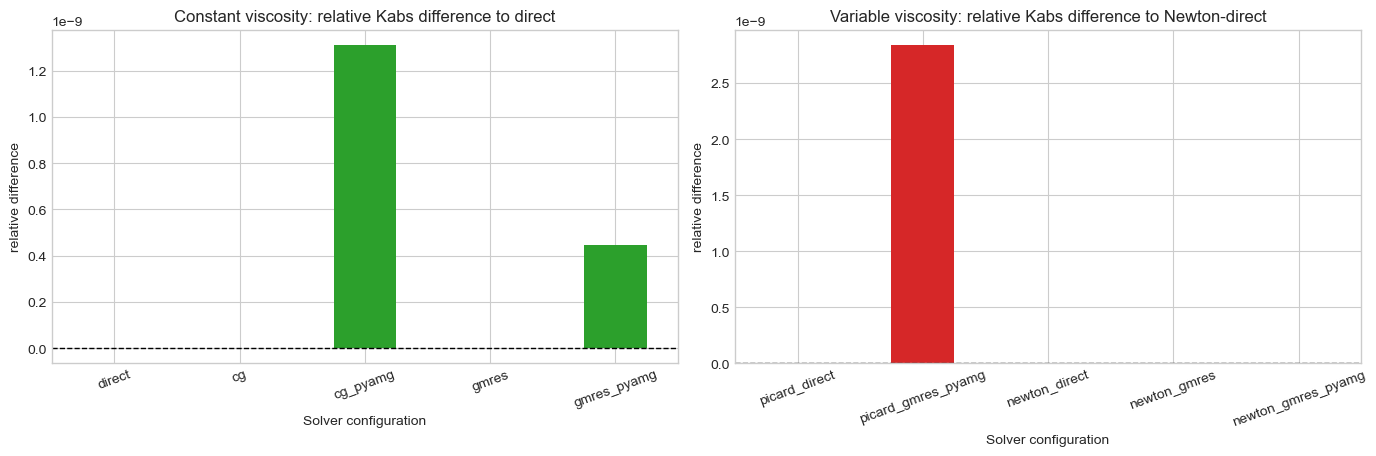

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

constant_df.plot(
    x="config",
    y="kabs_rel_diff_to_reference",
    kind="bar",
    ax=axes[0],
    legend=False,
    color="tab:green",
    rot=20,
)
axes[0].axhline(0.0, color="k", linestyle="--", linewidth=1.0)
axes[0].set_title("Constant viscosity: relative Kabs difference to direct")
axes[0].set_xlabel("Solver configuration")
axes[0].set_ylabel("relative difference")

variable_df.plot(
    x="config",
    y="kabs_rel_diff_to_reference",
    kind="bar",
    ax=axes[1],
    legend=False,
    color="tab:red",
    rot=20,
)
axes[1].axhline(0.0, color="k", linestyle="--", linewidth=1.0)
axes[1].set_title("Variable viscosity: relative Kabs difference to Newton-direct")
axes[1].set_xlabel("Solver configuration")
axes[1].set_ylabel("relative difference")

plt.tight_layout()
save_figure(fig, "solver_accuracy_bars.png")
finalize_figure(fig)

## Pareto-style view: accuracy vs runtime

The reference solves sit at zero relative error by construction. The more interesting question is
whether faster iterative/preconditioned configurations stay close enough to the same `Kabs`.

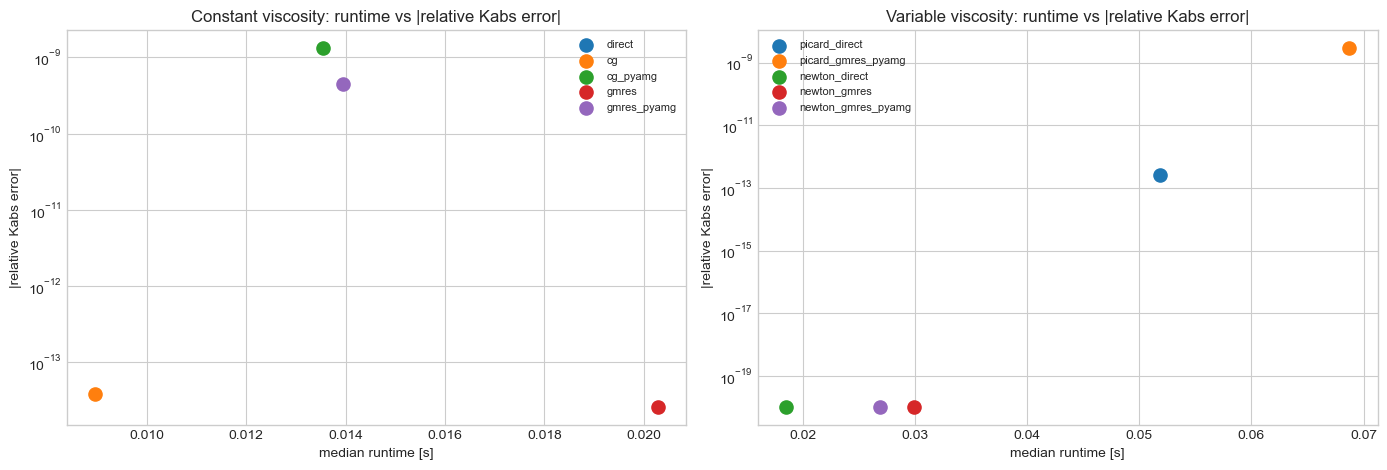

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for row in constant_df.itertuples(index=False):
    axes[0].scatter(
        row.time_median_s,
        abs(row.kabs_rel_diff_to_reference),
        s=90,
        label=row.config,
    )
axes[0].set_title("Constant viscosity: runtime vs |relative Kabs error|")
axes[0].set_xlabel("median runtime [s]")
axes[0].set_ylabel("|relative Kabs error|")
axes[0].set_yscale("log")
axes[0].legend(fontsize=8)

for row in variable_df.itertuples(index=False):
    axes[1].scatter(
        row.time_median_s,
        abs(row.kabs_rel_diff_to_reference) + 1.0e-20,
        s=90,
        label=row.config,
    )
axes[1].set_title("Variable viscosity: runtime vs |relative Kabs error|")
axes[1].set_xlabel("median runtime [s]")
axes[1].set_ylabel("|relative Kabs error|")
axes[1].set_yscale("log")
axes[1].legend(fontsize=8)

plt.tight_layout()
save_figure(fig, "runtime_vs_accuracy_scatter.png")
finalize_figure(fig)

## Nonlinear iteration count

For the variable-viscosity problem, wall time alone can be misleading. The next chart separates the
outer nonlinear work from the cost of each inner linear solve.

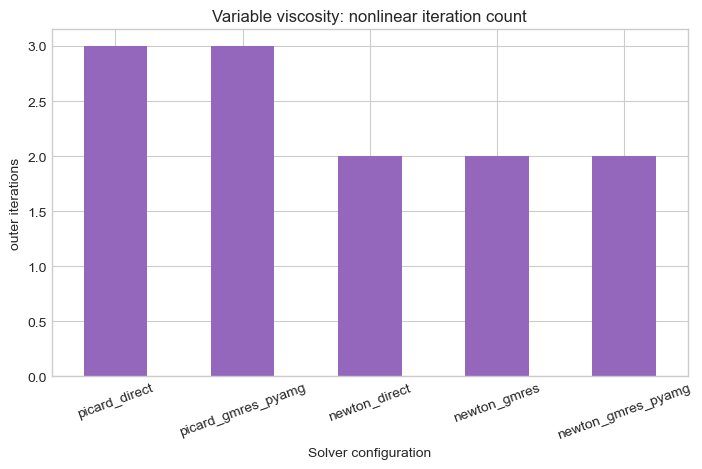

In [19]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
variable_df.plot(
    x="config",
    y="nonlinear_iterations",
    kind="bar",
    ax=ax,
    legend=False,
    color="tab:purple",
    rot=20,
)
ax.set_title("Variable viscosity: nonlinear iteration count")
ax.set_xlabel("Solver configuration")
ax.set_ylabel("outer iterations")
fig.tight_layout()
save_figure(fig, "nonlinear_iterations.png")
finalize_figure(fig)

## Direct-solver and PyAMG speedup factors

These ratios are often more interpretable than raw times because they answer the practical question:
"How much do I gain from turning this backend on?"

In [20]:
speedup_rows = []
if {"cg", "cg_pyamg"}.issubset(constant_df["config"].tolist()):
    base = float(
        constant_df.loc[constant_df["config"] == "cg", "time_median_s"].iloc[0]
    )
    accelerated = float(
        constant_df.loc[constant_df["config"] == "cg_pyamg", "time_median_s"].iloc[0]
    )
    speedup_rows.append({"case": "constant_cg", "speedup": base / accelerated})
if {"gmres", "gmres_pyamg"}.issubset(constant_df["config"].tolist()):
    base = float(
        constant_df.loc[constant_df["config"] == "gmres", "time_median_s"].iloc[0]
    )
    accelerated = float(
        constant_df.loc[constant_df["config"] == "gmres_pyamg", "time_median_s"].iloc[0]
    )
    speedup_rows.append({"case": "constant_gmres", "speedup": base / accelerated})
if {"newton_gmres", "newton_gmres_pyamg"}.issubset(variable_df["config"].tolist()):
    base = float(
        variable_df.loc[variable_df["config"] == "newton_gmres", "time_median_s"].iloc[
            0
        ]
    )
    accelerated = float(
        variable_df.loc[
            variable_df["config"] == "newton_gmres_pyamg", "time_median_s"
        ].iloc[0]
    )
    speedup_rows.append({"case": "newton_gmres", "speedup": base / accelerated})
if {"direct", "direct_umfpack"}.issubset(constant_df["config"].tolist()):
    base = float(
        constant_df.loc[constant_df["config"] == "direct", "time_median_s"].iloc[0]
    )
    accelerated = float(
        constant_df.loc[
            constant_df["config"] == "direct_umfpack", "time_median_s"
        ].iloc[0]
    )
    speedup_rows.append(
        {"case": "constant_direct_umfpack", "speedup": base / accelerated}
    )
if {"newton_direct", "newton_umfpack"}.issubset(variable_df["config"].tolist()):
    base = float(
        variable_df.loc[variable_df["config"] == "newton_direct", "time_median_s"].iloc[
            0
        ]
    )
    accelerated = float(
        variable_df.loc[
            variable_df["config"] == "newton_umfpack", "time_median_s"
        ].iloc[0]
    )
    speedup_rows.append(
        {"case": "newton_direct_umfpack", "speedup": base / accelerated}
    )
speedup_df = pd.DataFrame(speedup_rows)
speedup_df
save_table(speedup_df, "solver_speedup.csv")

,case,speedup
0,constant_cg,0.661247
1,constant_gmres,1.455238
2,newton_gmres,1.113059


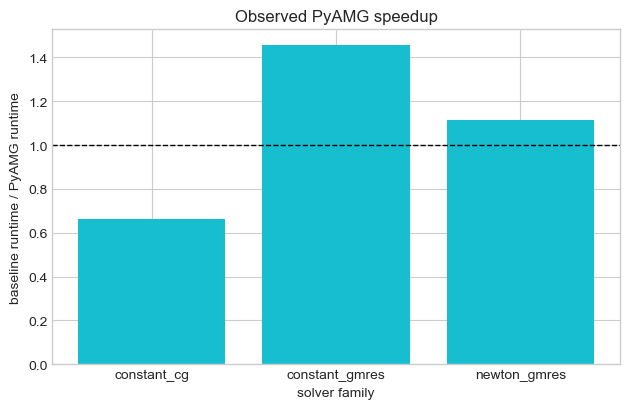

In [21]:
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(speedup_df["case"], speedup_df["speedup"], color="tab:cyan")
ax.axhline(1.0, color="k", linestyle="--", linewidth=1.0)
ax.set_title("Observed solver speedup")
ax.set_xlabel("solver family")
ax.set_ylabel("baseline runtime / selected runtime")
ax.tick_params(axis="x", labelrotation=25)
for label in ax.get_xticklabels():
    label.set_ha("right")
fig.tight_layout()
save_figure(fig, "solver_speedup.png")
finalize_figure(fig)

## FEM linear backend benchmark

The FEM comparison isolates the new `FEniCSSolverOptions.linear_backend` choices:

- `petsc_mumps`: DOLFINx assembly solved through the PETSc backend with MUMPS LU
- `scipy_spsolve`: DOLFINx assembly converted to SciPy sparse format and solved by
  `scipy.sparse.linalg.spsolve`
- `umfpack`: DOLFINx assembly converted to SciPy sparse format and solved by `scikits.umfpack`

These are linear-algebra backends for the same FEM formulation. They do not switch from FEM to
TPFA, LBM, or a different physical model. The pressure and velocity arrays are compared directly
against the PETSc run when PETSc is available; otherwise the first available serial direct backend
becomes the local reference.

In [ ]:
fem_df, fem_failures_df, fem_status_message = summarize_fem_backends()
print(fem_status_message)
if not fem_failures_df.empty:
    display(fem_failures_df)
fem_df
if not fem_df.empty:
    save_table(fem_df, "fem_linear_backend_benchmark.csv")
if not fem_failures_df.empty:
    save_table(fem_failures_df, "fem_linear_backend_failures.csv")

In [ ]:
if not fem_df.empty:
    fem_accuracy_df = fem_df.sort_values(["formulation", "cells", "backend"])[
        [
            "formulation",
            "cells",
            "backend",
            "resolved_backend",
            "reference_backend",
            "permeability_rel_diff_to_reference",
            "flow_rate_rel_diff_to_reference",
            "velocity_rel_l2_to_reference",
            "pressure_rel_l2_to_reference",
        ]
    ]
    display(fem_accuracy_df)

In [ ]:
if not fem_df.empty:
    fem_timing_df = fem_df.sort_values(["formulation", "cells", "time_median_s"])[
        [
            "formulation",
            "cells",
            "backend",
            "velocity_dofs",
            "pressure_dofs",
            "time_median_s",
            "time_min_s",
            "time_max_s",
            "reported_solve_seconds",
        ]
    ]
    display(fem_timing_df)

In [ ]:
if not fem_df.empty:
    fig, axes = plt.subplots(1, len(fem_formulations), figsize=(16, 4.6), sharey=True)
    for ax, (formulation, group) in zip(
        axes, fem_df.groupby("formulation"), strict=False
    ):
        pivot = group.pivot(index="cells", columns="backend", values="time_median_s")
        pivot.plot(kind="bar", ax=ax, rot=0)
        ax.set_title(formulation.replace("_", " "))
        ax.set_xlabel("map cells")
        ax.set_ylabel("median runtime [s]")
        ax.legend(fontsize=8)
    fig.suptitle("FEM linear backend runtime by formulation")
    fig.tight_layout()
    save_figure(fig, "fem_linear_backend_runtime.png")
    finalize_figure(fig)

In [ ]:
if not fem_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
    accuracy_columns = [
        "permeability_rel_diff_to_reference",
        "velocity_rel_l2_to_reference",
        "pressure_rel_l2_to_reference",
    ]
    for backend, group in fem_df.groupby("backend"):
        axes[0].scatter(
            group["time_median_s"],
            group["velocity_rel_l2_to_reference"].clip(lower=1.0e-18),
            s=80,
            label=backend,
        )
        axes[1].scatter(
            group["time_median_s"],
            group["pressure_rel_l2_to_reference"].clip(lower=1.0e-18),
            s=80,
            label=backend,
        )
    for ax, field in zip(axes, ["velocity", "pressure"], strict=True):
        ax.set_title(f"{field.capitalize()} field parity")
        ax.set_xlabel("median runtime [s]")
        ax.set_ylabel(f"{field} relative L2 difference")
        ax.set_yscale("log")
        ax.legend(fontsize=8)
    fig.tight_layout()
    save_figure(fig, "fem_field_parity_scatter.png")
    finalize_figure(fig)

In [ ]:
if not fem_df.empty:
    fem_summary_rows = []
    for backend, group in fem_df.groupby("backend"):
        non_reference = group[group["backend"] != group["reference_backend"]]
        comparison_group = non_reference if not non_reference.empty else group
        fem_summary_rows.append(
            {
                "backend": backend,
                "cases_completed": len(group),
                "median_runtime_s": group["time_median_s"].median(),
                "max_abs_k_rel_diff": group["permeability_rel_diff_to_reference"]
                .abs()
                .max(),
                "max_velocity_rel_l2": comparison_group[
                    "velocity_rel_l2_to_reference"
                ].max(),
                "max_pressure_rel_l2": comparison_group[
                    "pressure_rel_l2_to_reference"
                ].max(),
            }
        )
    fem_summary_df = pd.DataFrame(fem_summary_rows).sort_values("median_runtime_s")
    display(fem_summary_df)
    save_table(fem_summary_df, "fem_linear_backend_summary.csv")

## Reading the tables

Suggested interpretation:
- for constant viscosity, the main question is whether `cg + pyamg` or `gmres + pyamg` reduces
  runtime without changing `Kabs`
- for variable viscosity, the main question is whether Newton reduces outer iterations enough to
  offset the cost of assembling and solving the exact Jacobian
- for FEM, the main question is whether PETSc, SciPy, and UMFPACK produce the same permeability,
  flow rate, pressure field, and velocity field for the same weak form and coefficient maps
- if the `Kabs` and FEM field differences remain near machine precision, the benchmark is comparing
  linear algebra backends, not changing the physics

Suggested documentation use:
- the runtime bars are the high-level headline figure
- the runtime-vs-accuracy scatter is the defensible numerical-quality figure
- the nonlinear-iteration bar chart explains why Newton may outperform Picard even when each Newton
  iteration is more expensive
- the FEM field-parity table is the defensible check for the Windows-compatible direct sparse
  backends because matching permeability alone could hide local pressure or velocity differences